Dimensi data: (5000, 14)
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  

Missing values:
 ID                    0
Age                   0
Ex

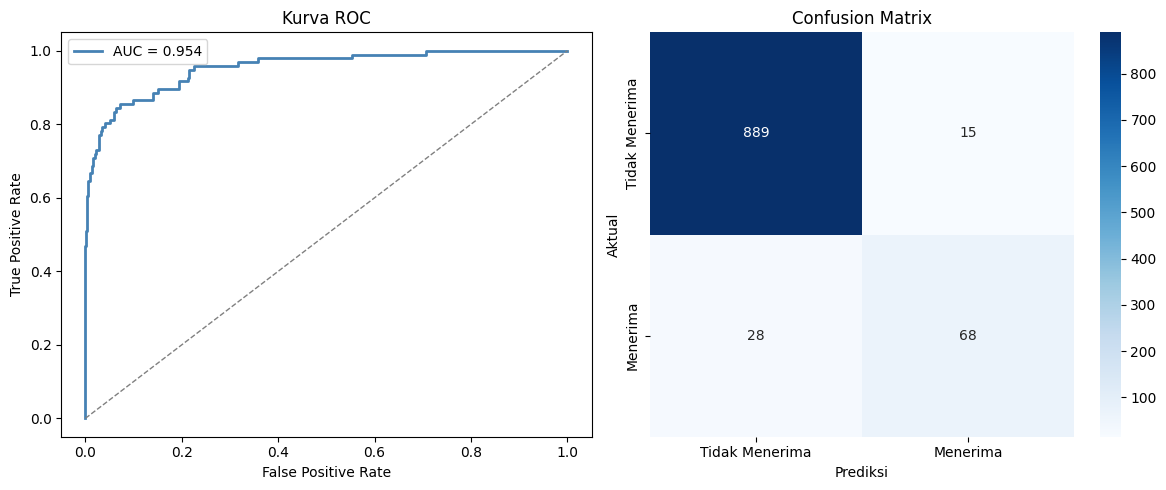

Plot tersimpan di output/evaluasi_model.png

=== KEBAIKAN MODEL ===
Pseudo R² (McFadden) : 0.5779
Log-Likelihood       : -667.3904
LL-Null              : -1581.0206
LLR p-value          : 0.0000e+00
AIC                  : 1346.7807
BIC                  : 1385.8839


In [1]:
# =========================================================
# ANALISIS REGRESI LOGISTIK BINER
# Studi Kasus: Penerimaan Pinjaman Pribadi (Personal Loan)
# Universal Bank Dataset
# Aufaa Zakki Maulidan
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── 1. LOAD DATA ──────────────────────────────────────────
DATA_PATH = "/content/DATA 2_Bank_Personal_Loan_Modelling.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"File tidak ditemukan: {DATA_PATH}\n"
        "Pastikan file Excel ada di folder 'data/'."
    )

df = pd.read_excel(DATA_PATH, sheet_name="Data")
print(f"Dimensi data: {df.shape}")
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

# ── 2. PREPROCESSING ──────────────────────────────────────
y = df["Personal Loan"]
X = df[["Income", "CCAvg", "Education", "Family"]].copy()
X = pd.get_dummies(X, columns=["Education"], drop_first=True)  # basis: Undergrad
X = X.astype(float)

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(df[["Income", "CCAvg", "Family"]].describe().round(3))
print("\nDistribusi Pendidikan:\n", df["Education"].value_counts())
print("\nProporsi Target:\n", df["Personal Loan"].value_counts(normalize=True).round(4))

# ── 3. ESTIMASI MODEL (MLE) - FULL DATA ───────────────────
Xc = sm.add_constant(X)
model = sm.Logit(y, Xc).fit()
print(model.summary())

# Odds Ratio + CI 95%
conf = model.conf_int()
conf["OR"] = model.params
conf.columns = ["2.5%", "97.5%", "OR"]
odds_ratio = np.exp(conf)
print("\nOdds Ratio:\n", odds_ratio.round(4))

# ── 4. VALIDASI - TRAIN/TEST SPLIT (80:20) ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    Xc, y, test_size=0.2, random_state=42, stratify=y
)
model_val = sm.Logit(y_train, X_train).fit(disp=False)
pred_prob  = model_val.predict(X_test)
pred_class = (pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred_class)
print("\nConfusion Matrix:\n", cm)
print(f"Accuracy  : {accuracy_score(y_test, pred_class):.4f}")
print(f"Precision : {precision_score(y_test, pred_class):.4f}")
print(f"Recall    : {recall_score(y_test, pred_class):.4f}")
print(f"F1-Score  : {f1_score(y_test, pred_class):.4f}")
print(f"AUC       : {roc_auc_score(y_test, pred_prob):.4f}")

# ── 5. VISUALISASI ────────────────────────────────────────
os.makedirs("output", exist_ok=True)

# a) Kurva ROC
fpr, tpr, _ = roc_curve(y_test, pred_prob)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"AUC = {roc_auc_score(y_test, pred_prob):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Kurva ROC")
axes[0].legend()

# b) Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tidak Menerima", "Menerima"],
            yticklabels=["Tidak Menerima", "Menerima"],
            ax=axes[1])
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("output/evaluasi_model.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot tersimpan di output/evaluasi_model.png")

# ── 6. RINGKASAN KEBAIKAN MODEL ───────────────────────────
print("\n=== KEBAIKAN MODEL ===")
print(f"Pseudo R² (McFadden) : {model.prsquared:.4f}")
print(f"Log-Likelihood       : {model.llf:.4f}")
print(f"LL-Null              : {model.llnull:.4f}")
print(f"LLR p-value          : {model.llr_pvalue:.4e}")
print(f"AIC                  : {model.aic:.4f}")
print(f"BIC                  : {model.bic:.4f}")